В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.datasets import make_classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/drive/Colab Notebooks')

In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/process_bank_churn.py" /content/


In [ ]:
import process_bank_churn

In [ ]:
# 1. Завантаження даних
df = pd.read_csv('drive/MyDrive/Colab Notebooks/train.csv')

# 2. Цільова колонка
target_col = "Exited"

# 3. Розбивка на train/val
train_df, val_df = process_bank_churn.split_data(df, target_col)
train_targets = train_df[target_col]
val_targets = val_df[target_col]
train_df.drop(columns=[target_col], inplace=True)
val_df.drop(columns=[target_col], inplace=True)

# 4. Колонки для дропу / інклуду
drop_cols = ["id", "CustomerId", "Surname"]
train_df = process_bank_churn.drop_columns(train_df, drop_cols)
val_df = process_bank_churn.drop_columns(val_df, drop_cols)

# 5. Типи колонок Визначаємо numeric / categorical — лише на train_df
numeric_cols, cat_cols = process_bank_churn.get_numeric_and_categorical_columns(train_df)

# 6. Масштабування
scaler = process_bank_churn.fit_scaler(train_df, numeric_cols) # Навчаємо scaler — лише на train_df[numeric_cols]
train_df = process_bank_churn.transform_scaler(train_df, scaler, numeric_cols) #Застосовуємо scaler до train_df та val_df — використовуючи ті ж numeric_cols
val_df = process_bank_churn.transform_scaler(val_df, scaler, numeric_cols) #Застосовуємо scaler до train_df та val_df — використовуючи ті ж numeric_cols

# Onehot
geo_encoder = process_bank_churn.fit_onehot_encoder(train_df, "Geography")
train_df, val_df = process_bank_churn.encode_column(train_df, val_df, "Geography", geo_encoder)

# 7. Бінарне кодування Gender
train_df = process_bank_churn.encode_binary_column(train_df, "Gender", "Female")
val_df = process_bank_churn.encode_binary_column(val_df, "Gender", "Female")


# 9. Готові результати
X_train = train_df.copy()
X_val = val_df.copy()


In [ ]:
display(X_train, train_targets)
display(X_val , val_targets)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7180,0.320187,0,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0
10393,0.347838,1,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0
80,0.638166,0,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0
3365,0.140460,0,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0
12236,0.665816,0,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9493,-0.357246,1,-0.576046,-0.368848,-0.717950,0.769304,-1.941514,-0.983306,0.121626,1.0,0.0,0.0
8463,0.195761,1,0.284106,-1.447264,-0.717950,-1.108193,0.515062,1.016977,-1.539006,1.0,0.0,0.0
8143,-0.523147,0,-1.067561,1.069040,-0.717950,0.769304,0.515062,1.016977,0.340946,1.0,0.0,0.0
11512,-0.951727,0,0.529864,0.709568,-0.717950,0.769304,-1.941514,-0.983306,-0.994754,0.0,0.0,1.0


,Exited
7180,0.0
10393,0.0
80,0.0
3365,0.0
12236,0.0
...,...
9493,0.0
8463,0.0
8143,0.0
11512,0.0


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
6490,0.762592,0,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,0.0,1.0,0.0
3646,-0.910252,0,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,1.0,0.0,0.0
5306,0.997620,1,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,1.0,0.0,0.0
652,0.195761,1,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,1.0,0.0,0.0
2627,0.264887,1,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10550,0.264887,0,0.038348,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.340946,1.0,0.0,0.0
8866,1.301774,0,2.004409,0.350096,-0.717950,-1.108193,0.515062,-0.983306,1.295810,1.0,0.0,0.0
3244,0.264887,0,-0.698924,-0.009376,-0.717950,0.769304,0.515062,-0.983306,1.288074,0.0,0.0,1.0
12441,0.900844,0,-0.576046,-0.009376,1.588442,-1.108193,0.515062,-0.983306,-0.269203,0.0,0.0,1.0


,Exited
6490,1.0
3646,0.0
5306,0.0
652,0.0
2627,0.0
...,...
10550,0.0
8866,1.0
3244,0.0
12441,0.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [ ]:
knn = KNeighborsClassifier() # 1. Створюємо модель з параметрами за замовченням

In [ ]:
knn.fit(X_train, train_targets) # 2. Навчаємо на тренувальних даних

KNeighborsClassifier()

In [ ]:
train_probs = knn.predict_proba(X_train)[:, 1] # 3. Отримуємо ймовірності приналежності до позитивного класу (1)
val_probs = knn.predict_proba(X_val)[:, 1]

In [ ]:
train_auroc = roc_auc_score(train_targets, train_probs) # 4. Розраховуємо AUROC
val_auroc = roc_auc_score(val_targets, val_probs)

In [ ]:
print(f"Train AUROC: {train_auroc:.4f}")
print(f"Validation AUROC: {val_auroc:.4f}")

Train AUROC: 0.9620
Validation AUROC: 0.8755


**Висновок**

Високий результат на тренуванні й помірне падіння на валідації свідчить про незначний overfitting → легкий high variance.\
Але обидва значення AUROC вище 0.85, тому загалом модель хороша.\
Немає ознак high bias — модель добре вивчила тренувальні дані.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [ ]:
knn1 = KNeighborsClassifier()

In [ ]:
# Визначаємо сітку параметрів
param_grid = {'n_neighbors': list(range(1, 31))}

In [ ]:
# Налаштовуємо GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc')

In [ ]:
# Навчаємо на тренувальних даних
grid_search.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='roc_auc')

In [ ]:
print("Найкраще значення n_neighbors:", grid_search.best_params_['n_neighbors'])
print("Найкращий середній AUROC (крос-валідація):", grid_search.best_score_)

Найкраще значення n_neighbors: 25
Найкращий середній AUROC (крос-валідація): 0.9133879311513642


**ВИСНОВОК**\
KNeighborsClassifier	~0.9342	 0.9134\
DecisionTreeClassifier	0.9342	0.9187\
Дерево трохи виграє на валідаційній вибірці, хоча різниця невелика.
KNN зазвичай більш стабільний і менше схильний до оверфітінгу, особливо при великому n_neighbors.
Дерево може підлаштуватися сильніше під конкретні патерни — і це було видно до пошуку найкращої глибини, був явний оверфіт на тренувальних даних, у першій ітерації

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [ ]:
clf = DecisionTreeClassifier(random_state=42)

In [ ]:
#Сітка параметрів
param_grid = {
    'max_depth': list(range(1, 21, 2)),
    'max_leaf_nodes': list(range(2, 11))
}

In [ ]:
start_time = time.time()

In [ ]:
# Пошук гіперпараметрів
grid_search = GridSearchCV( clf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, train_targets)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='roc_auc')

In [ ]:
end_time = time.time()
execution_time = end_time - start_time

In [ ]:
print("Найкращі гіперпараметри:", grid_search.best_params_)
print("Найкраще значення ROC AUC:", round(grid_search.best_score_, 4))
print("Час виконання пошуку:", round(execution_time, 2), "секунд")

Найкращі гіперпараметри: {'max_depth': 5, 'max_leaf_nodes': 10}
Найкраще значення ROC AUC: 0.9014
Час виконання пошуку: 7.34 секунд


**Висновок**\
Ця модель майже така сама, вручну значення глибини дерева було приблизно 6, а тут 5

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [ ]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [ ]:
clf1 = DecisionTreeClassifier(random_state=42)

In [ ]:
start_time = time.time()

In [ ]:
#Пошук з RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=clf, param_distributions=params_dt, n_iter=40, scoring='roc_auc',cv=3, random_state=42, n_jobs=-1)


In [ ]:
#Навчання
random_search.fit(X_train, train_targets)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [ ]:
end_time = time.time()
execution_time = round(end_time - start_time, 2)

In [ ]:
print("Найкращі гіперпараметри:", random_search.best_params_)

Найкращі гіперпараметри: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


In [ ]:
# Найкраща модель
dt_random_search_best = random_search.best_estimator_

In [ ]:
# AUROC train/val
train_preds = dt_random_search_best.predict_proba(X_train)[:, 1]
val_preds = dt_random_search_best.predict_proba(X_val)[:, 1]

In [ ]:
train_auc = roc_auc_score(train_targets, train_preds)
val_auc = roc_auc_score(val_targets, val_preds)

In [ ]:
print("Час пошуку:", execution_time, "секунд")
print("AUROC на train:", round(train_auc, 4))
print("AUROC на val:", round(val_auc, 4))

Час пошуку: 1.5 секунд
AUROC на train: 0.9169
AUROC на val: 0.9166


**Висновки**
Бест гіпер параметри здались слабуватими, але вони дали гарні результати і немає явного оверфіту.\
Модель стабільно працює і на нових даних.


**це в нас найкращі параметри**\.     
'splitter': 'best', \
'min_samples_split': 20, \
'min_samples_leaf': 2, \
'max_leaf_nodes': 14, \
'max_features': None, \
'max_depth': 16, '\
criterion': 'entropy'

**params_dt** = \
    'criterion': ['gini', 'entropy'],\
    'splitter': ['best', 'random'],\
    'max_depth': np.arange(1, 20),\
    'max_leaf_nodes': np.arange(2, 20),\
    'min_samples_split': [2, 5, 10, 20],\
    'min_samples_leaf': [1, 2, 4, 8],\
    'max_features': [None, 'sqrt', 'log2']

 **dt_random_search_best** виглядає як консервативний варіант: стримує розгалуження, менше листів, менше глибини - стабільна, не надто глибока модель.\

**dt_best** — агресивніший, дозволяє моделі рости вглиб, що може дати вище AUROC, але з ризиком перенавчання.

 **Ентропія** трохи повільніше ніж **джині**

 **max_features** - sqrt розглядає мало фічей, але в нашому випадку 'max_features': None розглянуло всі, можливо вони всі є важливими, іх і так не багато.

**max_depth**: np.arange(1, 20) у нас 16, максимальна глибина, можливий оверфіт при максимальній глибині

**max_leaf_nodes**: np.arange(2, 20), у нас 'max_leaf_nodes': 14 , обмеження кількості листків приводить до зменшення складності моделі, тобто 2 це занадто проста модель, що призведе до андерфіту.

**min_samples_split**: [2, 5, 10, 20] у нас 'min_samples_split': 20 , обмеження розщеплення вузлів також може призвести до андерфіту при малій кількості вузлів, як результат пропустити важливі розщеплення

**min_samples_leaf**: [1, 2, 4, 8] у нас 'min_samples_leaf': 2 мінімальна кількість зразків, якщо дуже мала 1 - 2 наприклад, то може бути оверфітінг.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [ ]:
test_df_raw = pd.read_csv('drive/MyDrive/Colab Notebooks/test.csv')

In [ ]:
test_df_raw[:1]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86


In [ ]:
def fix_missing_onehot_columns(encoded_df, encoder, col_name):
    # Гарантуємо, що всі очікувані one-hot фічі присутні
    expected_cols = list(encoder.get_feature_names_out([col_name]))
    current_cols = list(encoded_df.columns)

    for expected_col in expected_cols:
        if expected_col not in current_cols:
            encoded_df[expected_col] = 0

    # Вирівнюємо порядок колонок
    encoded_df = encoded_df[expected_cols]
    return encoded_df


def preprocess_test_data(df_test, drop_cols, numeric_cols, scaler, geo_encoder):
    df_processed = df_test.copy()

    # Дроп непотрібних колонок
    df_processed = df_processed.drop(columns=drop_cols)

    # Масштабування числових ознак
    df_processed[numeric_cols] = scaler.transform(df_processed[numeric_cols])

    # One-hot кодування 'Geography'
    encoded = geo_encoder.transform(df_processed[["Geography"]])
    encoded_df = pd.DataFrame(
        encoded,
        columns=geo_encoder.get_feature_names_out(["Geography"]),
        index=df_processed.index
    )

    # Фіксація відсутніх колонок
    encoded_df = fix_missing_onehot_columns(encoded_df, geo_encoder, "Geography")

    # Об'єднуємо з основним DataFrame
    df_processed = pd.concat([df_processed.drop(columns=["Geography"]), encoded_df], axis=1)

    # Бінарне кодування 'Gender'
    df_processed["Gender"] = (df_processed["Gender"] == "Female").astype(int)

    return df_processed


In [ ]:
X_test = preprocess_test_data(test_df_raw, drop_cols, numeric_cols, scaler, geo_encoder)


In [ ]:
X_test

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-1.034678,0,-0.944682,-1.087792,1.720173,-1.108193,0.515062,1.016977,0.875226,0.0,1.0,0.0
1,-1.490909,0,0.161227,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.109098,1.0,0.0,0.0
2,0.651991,0,0.652742,1.069040,-0.717950,0.769304,0.515062,-0.983306,0.850584,1.0,0.0,0.0
3,0.804068,0,0.898500,-0.728320,-0.717950,-1.108193,0.515062,1.016977,1.073044,0.0,0.0,1.0
4,-0.924077,0,0.652742,1.069040,-0.717950,0.769304,0.515062,1.016977,0.563521,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.274295,0,0.038348,1.787983,-0.717950,0.769304,0.515062,1.016977,-1.499416,0.0,0.0,1.0
9996,0.264887,0,0.161227,1.428511,-0.717950,0.769304,0.515062,1.016977,0.537890,0.0,0.0,1.0
9997,1.592102,0,-0.944682,1.428511,-0.717950,0.769304,0.515062,-0.983306,-2.481612,1.0,0.0,0.0
9998,-0.882602,0,0.038348,0.350096,1.700511,-1.108193,0.515062,-0.983306,0.185943,1.0,0.0,0.0


In [ ]:
test_preds = dt_random_search_best.predict(X_test)

In [ ]:
test_probs = dt_random_search_best.predict_proba(X_test)[:, 1]  # для бінарної класифікації


In [ ]:
# Формуємо фінальний submission
sample_submission = pd.read_csv('drive/MyDrive/Colab Notebooks/sample_submission.csv')
sample_submission['Exited'] = test_probs
sample_submission.to_csv('submission_log_reg.csv', index=False)

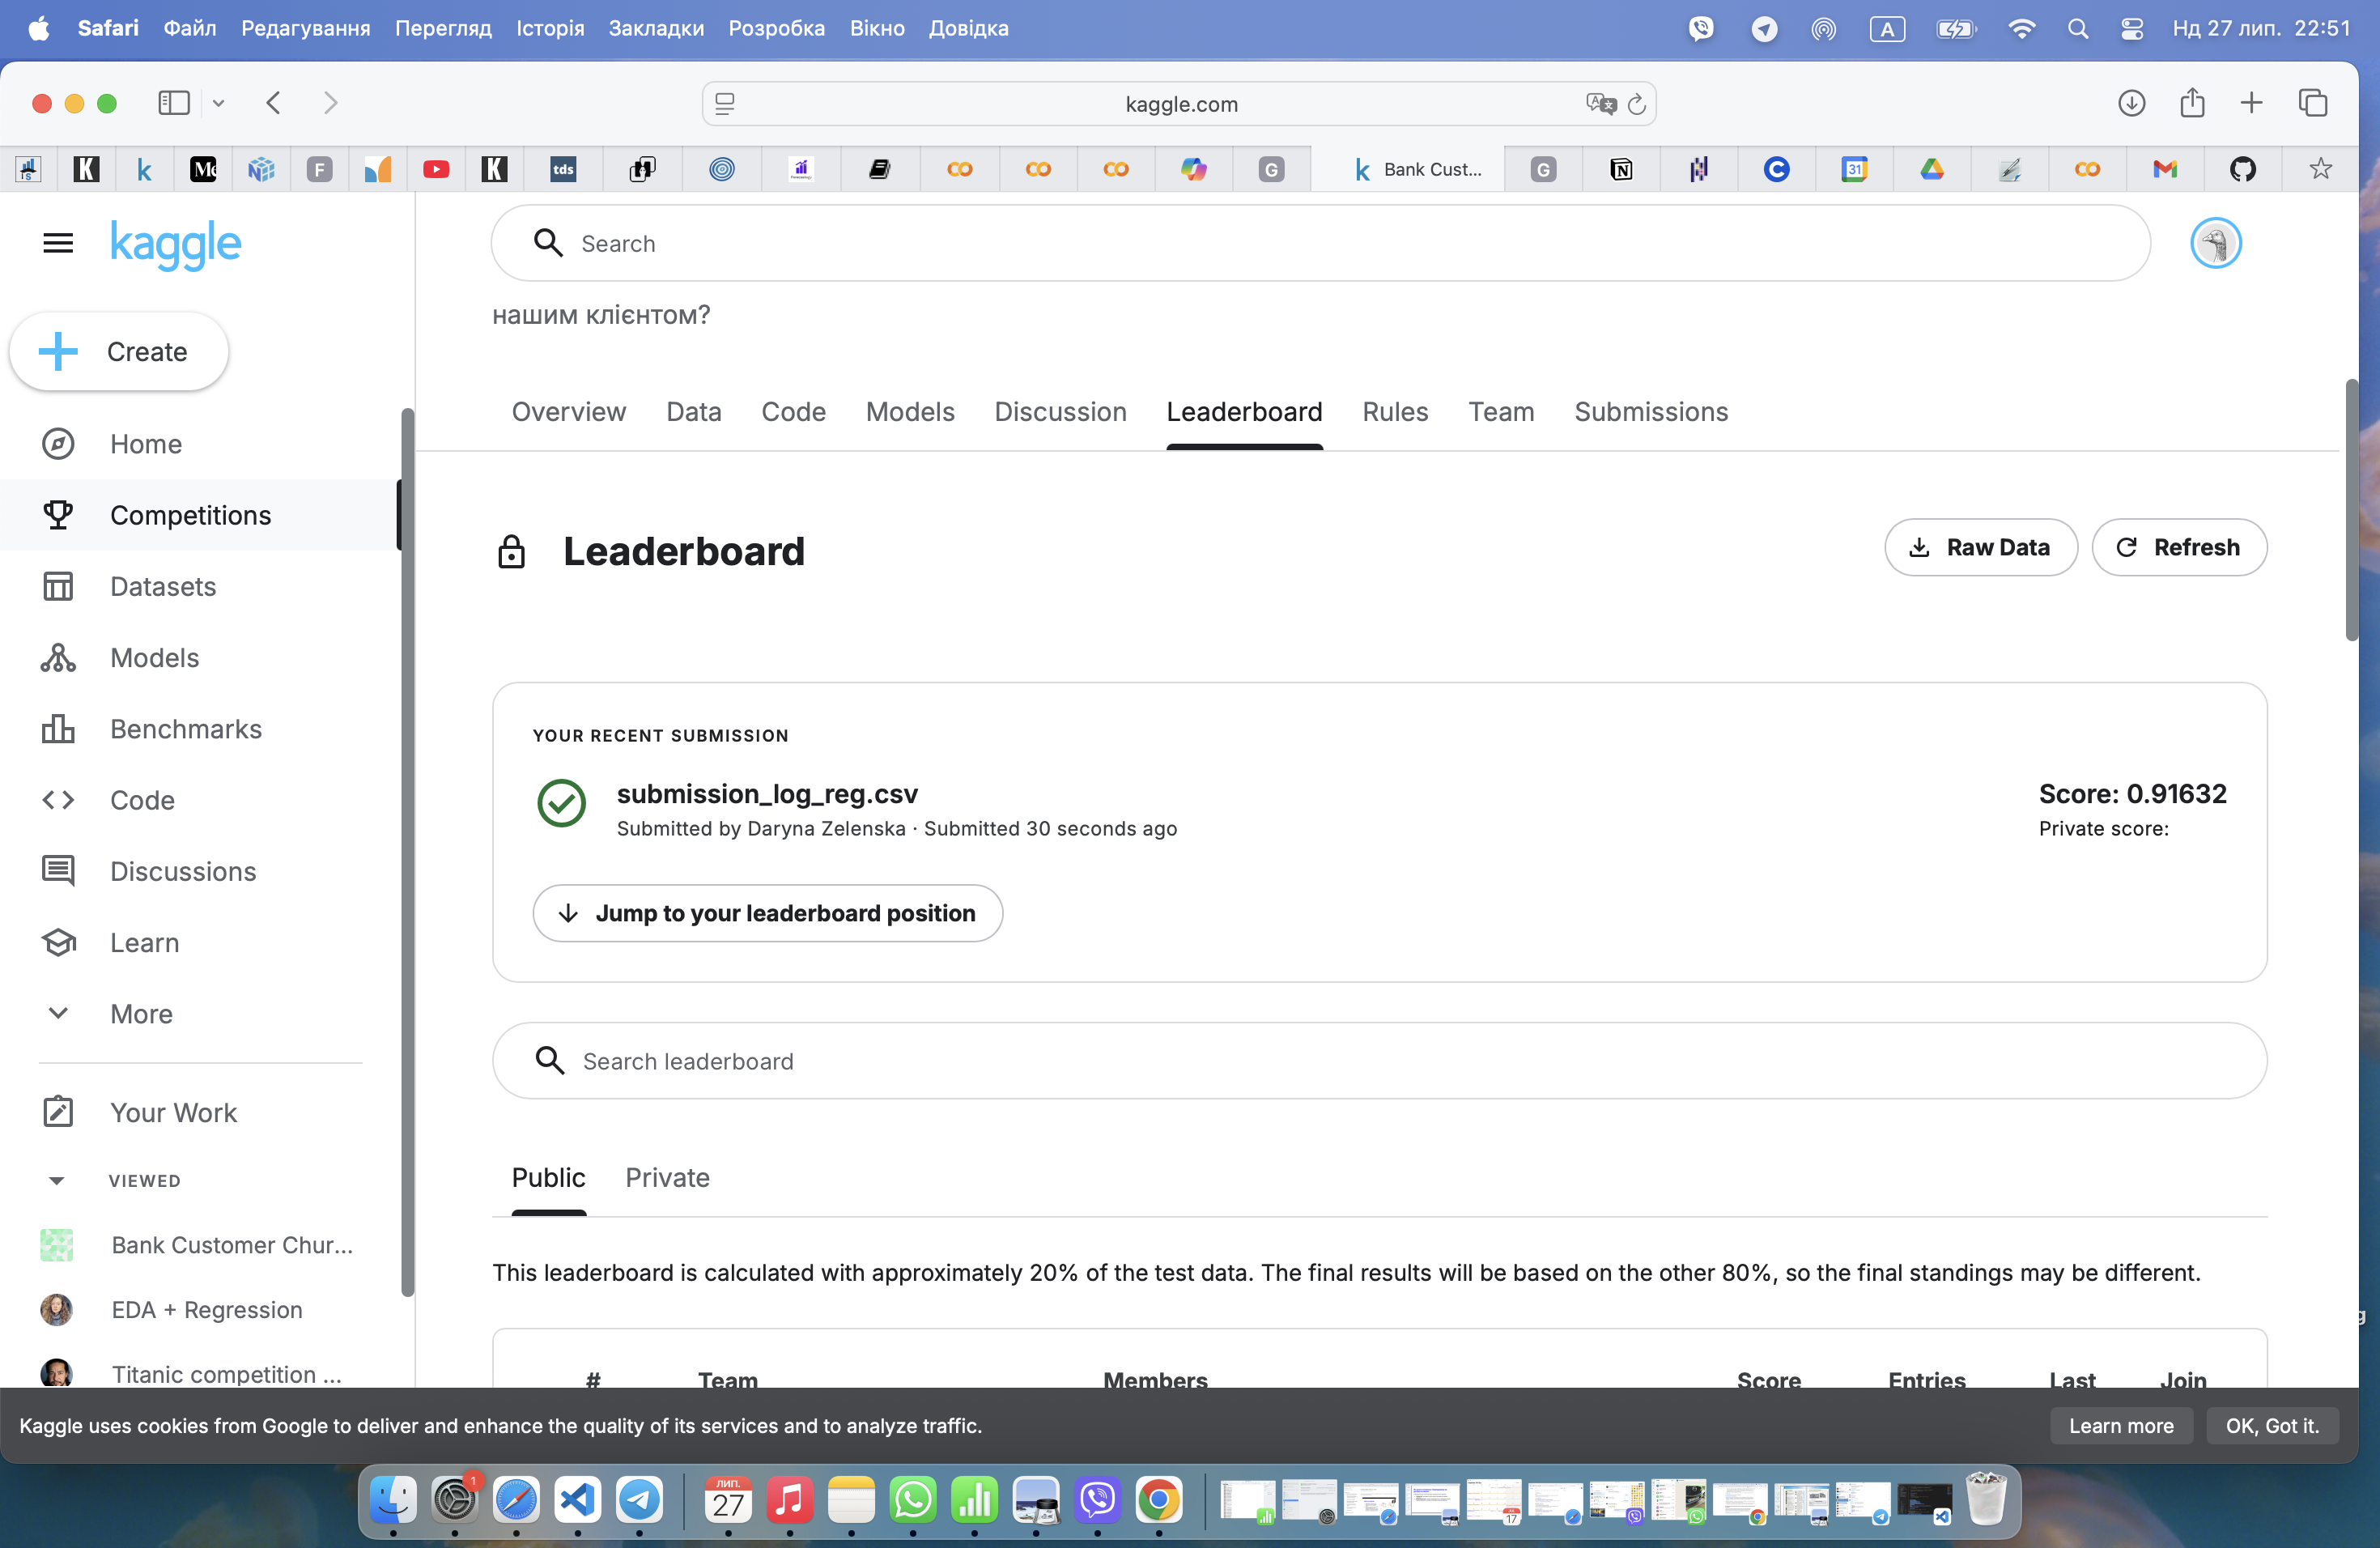